In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('spam.csv', encoding='latin-1')
print(df.shape)
df.head()

(5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
# Keep only useful columns and rename them
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

# Check for nulls
print(df.isnull().sum())
print("\nSpam vs Ham count:")
print(df['label'].value_counts())

label      0
message    0
dtype: int64

Spam vs Ham count:
label
ham     4825
spam     747
Name: count, dtype: int64


/var/folders/25/9qw4nn256pzdpxsczbj7_bxh0000gn/T/ipykernel_9080/3846663850.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='Set2')


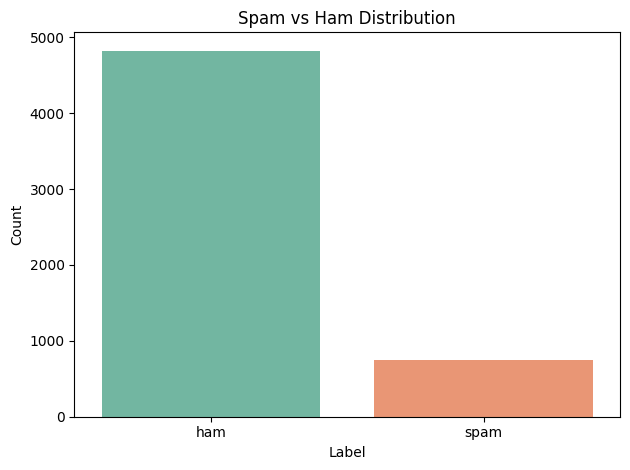

label
ham      71.023627
spam    138.866131
Name: msg_length, dtype: float64

In [4]:
# Visualize spam vs ham distribution
sns.countplot(x='label', data=df, palette='Set2')
plt.title('Spam vs Ham Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Message length analysis
df['msg_length'] = df['message'].apply(len)
df.groupby('label')['msg_length'].mean()

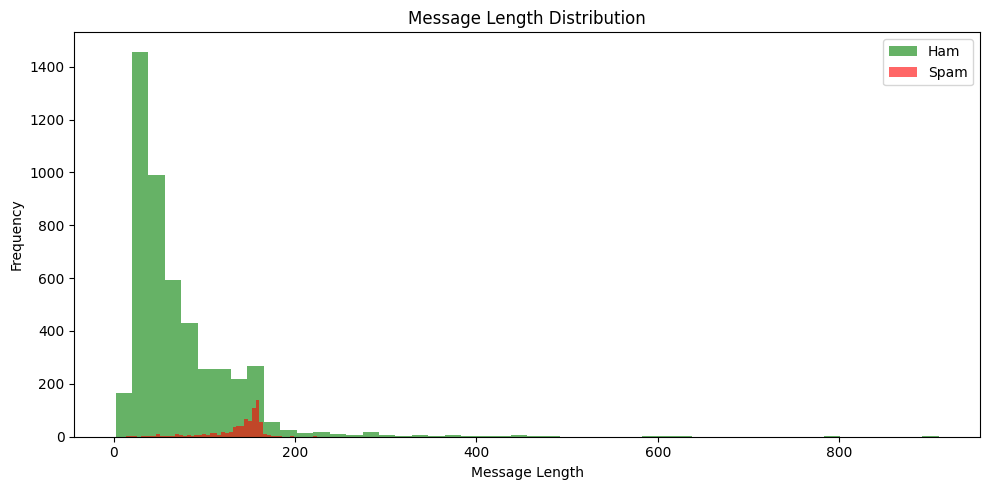

In [5]:
# Message length distribution by label
plt.figure(figsize=(10, 5))
df[df['label']=='ham']['msg_length'].plot(kind='hist', bins=50, alpha=0.6, label='Ham', color='green')
df[df['label']=='spam']['msg_length'].plot(kind='hist', bins=50, alpha=0.6, label='Spam', color='red')
plt.title('Message Length Distribution')
plt.xlabel('Message Length')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

import ssl
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

import nltk
nltk.download('stopwords')

ps = PorterStemmer()

def preprocess(text):
    # Remove non-alphabet characters
    text = re.sub('[^a-zA-Z]', ' ', text)
    # Lowercase
    text = text.lower()
    # Split into words
    words = text.split()
    # Remove stopwords and apply stemming
    words = [ps.stem(w) for w in words if w not in stopwords.words('english')]
    return ' '.join(words)

df['cleaned'] = df['message'].apply(preprocess)
df[['message', 'cleaned']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/koushikk/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,message,cleaned
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode labels: ham=0, spam=1
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])

# Split data
X = df['cleaned']
y = df['label_enc']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=3000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training set size:", X_train_tfidf.shape)
print("Test set size:", X_test_tfidf.shape)

Training set size: (4457, 3000)
Test set size: (1115, 3000)


In [9]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train model
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# Predict
y_pred = model.predict(X_test_tfidf)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

Accuracy: 0.9721973094170404

Classification Report:
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       965
        Spam       1.00      0.79      0.88       150

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115



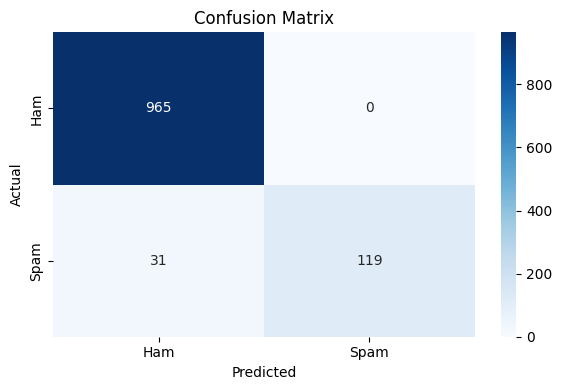

In [10]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [11]:
def predict_message(message):
    cleaned = preprocess(message)
    vectorized = tfidf.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    probability = model.predict_proba(vectorized)[0]
    
    label = "🚨 SPAM" if prediction == 1 else "✅ HAM"
    print(f"Message: {message}")
    print(f"Prediction: {label}")
    print(f"Confidence — Ham: {probability[0]:.2f} | Spam: {probability[1]:.2f}")

# Test it!
predict_message("Congratulations! You've won a free iPhone. Click here to claim now!")
predict_message("Hey, are we still meeting tomorrow for lunch?")

Message: Congratulations! You've won a free iPhone. Click here to claim now!
Prediction: 🚨 SPAM
Confidence — Ham: 0.13 | Spam: 0.87
Message: Hey, are we still meeting tomorrow for lunch?
Prediction: ✅ HAM
Confidence — Ham: 1.00 | Spam: 0.00


In [12]:
import pickle

# Save model and vectorizer
with open('spam_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("Model and vectorizer saved successfully! ✅")

Model and vectorizer saved successfully! ✅
